C:\Users\quzho2904\AppData\Local\Temp\ipykernel_35172\3283887065.py:157: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand[valid], z_int[valid])


u_depth actual = 200.0 m
A(u)           = 1.017e+07 m^2
d(rho)/dz @u   = 2.461481e-04
Integral term  = -6.089524e-01
k(u)           = 2.433422e-04 m^2/s
Saved mixing profile data to:
C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_result_station135_2022_vs_station15_2024.csv


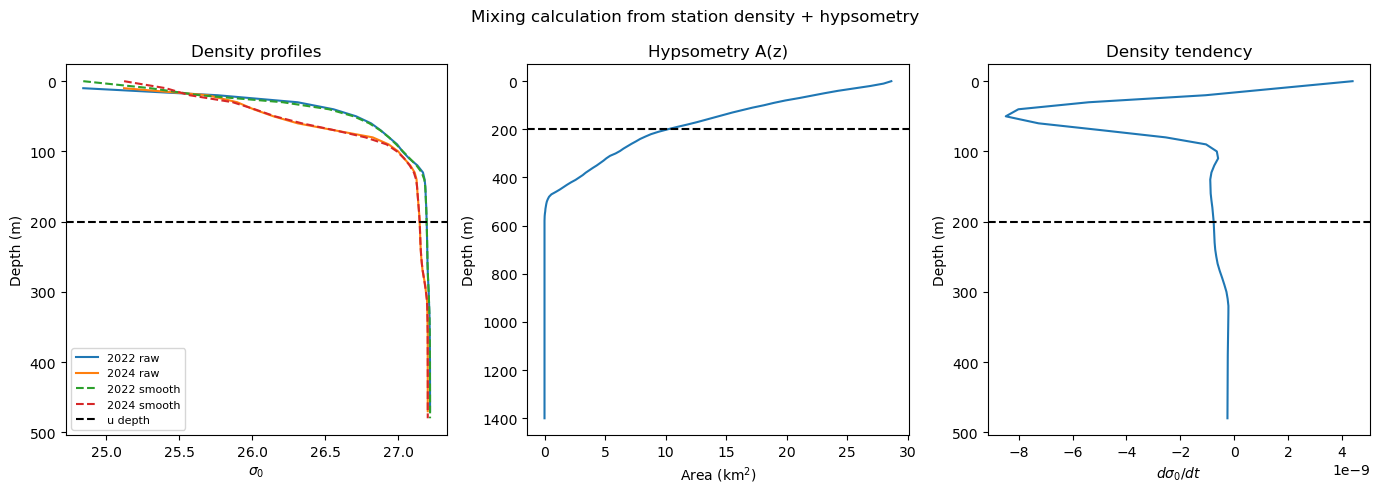

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Load hypsometry
# =========================================================
def load_hypsometry_csv(hyp_csv):
    df = pd.read_csv(hyp_csv)

    required_cols = ["depth_m", "area_m2"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Hypsometry file missing column: {col}")

    z_hyp = df["depth_m"].to_numpy(dtype=float)
    area_z = df["area_m2"].to_numpy(dtype=float)

    volume_z = None
    if "volume_m3" in df.columns:
        volume_z = df["volume_m3"].to_numpy(dtype=float)

    idx = np.argsort(z_hyp)
    z_hyp = z_hyp[idx]
    area_z = area_z[idx]
    if volume_z is not None:
        volume_z = volume_z[idx]

    return z_hyp, area_z, volume_z, df


# =========================================================
# 2. Load saved single-station sigma0 profile
# =========================================================
def load_sigma_station_csv(sig_csv):
    df = pd.read_csv(sig_csv)

    required_cols = ["depth_m", "sigma0_2022", "sigma0_2024"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Sigma file missing column: {col}")

    z_obs = df["depth_m"].to_numpy(dtype=float)
    rho1 = df["sigma0_2022"].to_numpy(dtype=float)
    rho2 = df["sigma0_2024"].to_numpy(dtype=float)

    return z_obs, rho1, rho2, df


# =========================================================
# 3. Interpolate profile onto hypsometry depth grid
# =========================================================
def interp_profile_to_grid(z_obs, rho_obs, z_grid):
    z_obs = np.asarray(z_obs, dtype=float)
    rho_obs = np.asarray(rho_obs, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)

    mask = np.isfinite(z_obs) & np.isfinite(rho_obs)
    z_obs = z_obs[mask]
    rho_obs = rho_obs[mask]

    if len(z_obs) < 2:
        raise ValueError("Insufficient valid observations for interpolation")

    idx = np.argsort(z_obs)
    z_obs = z_obs[idx]
    rho_obs = rho_obs[idx]

    rho_grid = np.interp(z_grid, z_obs, rho_obs, left=np.nan, right=np.nan)

    zmin = np.nanmin(z_obs)
    zmax = np.nanmax(z_obs)
    rho_grid[(z_grid < zmin) | (z_grid > zmax)] = np.nan

    return rho_grid


# =========================================================
# 4. Simple smoothing
# =========================================================
def moving_average_nan(x, window=3):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan)

    half = window // 2
    for i in range(len(x)):
        i0 = max(0, i - half)
        i1 = min(len(x), i + half + 1)
        seg = x[i0:i1]
        if np.isfinite(seg).sum() > 0:
            y[i] = np.nanmean(seg)

    return y


# =========================================================
# 5. Compute vertical diffusivity k(u)
# =========================================================
def compute_vertical_diffusivity(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth,
    smooth_window=3,
    use_abs_value=True
):
    """
    Compute vertical diffusivity k(u)
    using a representative station profile + hypsometry.

    Formula concept:

        k(u) = [ ∫_u^b A(z) * d(rho)/dt dz ] 
               / [ A(u) * d(rho)/dz |_u ]

    Depth z increases downward.
    Integration is performed from depth u to basin bottom.
    """

    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)
    rho_t1 = np.asarray(rho_t1, dtype=float)
    rho_t2 = np.asarray(rho_t2, dtype=float)

    delta_t_sec = delta_t_days * 24 * 3600.0

    # slight smoothing mainly to stabilize d(rho)/dz
    rho1_s = moving_average_nan(rho_t1, window=smooth_window)
    rho2_s = moving_average_nan(rho_t2, window=smooth_window)

    # d(rho)/dt
    drho_dt = (rho2_s - rho1_s) / delta_t_sec

    # find grid index closest to depth u
    u_index = np.argmin(np.abs(z_grid - u_depth))
    u_depth_actual = z_grid[u_index]

    # vertical density gradient at u
    drho_dz = np.gradient(rho2_s, z_grid)
    drho_dz_u = drho_dz[u_index]

    A_u = area_z[u_index]

    # integrate from u downward
    mask_int = z_grid >= u_depth_actual
    z_int = z_grid[mask_int]
    integrand = area_z[mask_int] * drho_dt[mask_int]

    valid = np.isfinite(z_int) & np.isfinite(integrand)

    if valid.sum() < 2:
        raise ValueError("Not enough valid data points in integration interval")

    integral_term = np.trapz(integrand[valid], z_int[valid])

    denominator = A_u * drho_dz_u

    if not np.isfinite(denominator) or denominator == 0:
        raise ValueError("Denominator A(u)*d(rho)/dz is invalid or zero")

    k_u = integral_term / denominator

    if use_abs_value:
        k_u = np.abs(k_u)

    return {
        "k_u": k_u,
        "u_depth_actual": u_depth_actual,
        "u_index": u_index,
        "A_u": A_u,
        "drho_dz_u": drho_dz_u,
        "integral_term": integral_term,
        "drho_dt": drho_dt,
        "rho1_s": rho1_s,
        "rho2_s": rho2_s
    }


# =========================================================
# 6. Diagnostic plots
# =========================================================
def plot_mixing_check(z_grid, area_z, rho1_grid, rho2_grid, result, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # density profiles
    axes[0].plot(rho1_grid, z_grid, label="2022 raw")
    axes[0].plot(rho2_grid, z_grid, label="2024 raw")
    axes[0].plot(result["rho1_s"], z_grid, "--", label="2022 smooth")
    axes[0].plot(result["rho2_s"], z_grid, "--", label="2024 smooth")
    axes[0].axhline(result["u_depth_actual"], color="k", linestyle="--", label="u depth")

    axes[0].invert_yaxis()
    axes[0].set_xlabel(r"$\sigma_0$")
    axes[0].set_ylabel("Depth (m)")
    axes[0].set_title("Density profiles")
    axes[0].legend(fontsize=8)

    # basin area curve
    axes[1].plot(area_z / 1e6, z_grid)
    axes[1].axhline(result["u_depth_actual"], color="k", linestyle="--")

    axes[1].invert_yaxis()
    axes[1].set_xlabel("Area (km$^2$)")
    axes[1].set_ylabel("Depth (m)")
    axes[1].set_title("Hypsometry A(z)")

    # density tendency
    axes[2].plot(result["drho_dt"], z_grid)
    axes[2].axhline(result["u_depth_actual"], color="k", linestyle="--")

    axes[2].invert_yaxis()
    axes[2].set_xlabel(r"$d\sigma_0/dt$")
    axes[2].set_ylabel("Depth (m)")
    axes[2].set_title("Density tendency")

    fig.suptitle(title)

    plt.tight_layout()
    plt.show()


# =========================================================
# 7. Save results
# =========================================================
def save_mixing_result_csv(save_csv, z_grid, area_z, rho1_grid, rho2_grid, result):

    df_out = pd.DataFrame({
        "depth_m": z_grid,
        "area_m2": area_z,
        "sigma0_2022_interp": rho1_grid,
        "sigma0_2024_interp": rho2_grid,
        "sigma0_2022_smooth": result["rho1_s"],
        "sigma0_2024_smooth": result["rho2_s"],
        "drho_dt": result["drho_dt"]
    })

    df_out.to_csv(save_csv, index=False, encoding="utf-8-sig")


# =========================================================
# 8. Main program
# =========================================================
if __name__ == "__main__":

    # -----------------------------------------------------
    # File paths: adjust to your own system
    # -----------------------------------------------------
    hyp_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonGE5.30_lat60.775_60.925.csv"

    sig_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station135_2022_vs_station15_2024.csv"


    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------
    z_hyp, area_z, volume_z, df_hyp = load_hypsometry_csv(hyp_csv)

    z_obs, rho1_obs, rho2_obs, df_sig = load_sigma_station_csv(sig_csv)


    # -----------------------------------------------------
    # Interpolate onto hypsometry depth grid
    # -----------------------------------------------------
    rho1_grid = interp_profile_to_grid(z_obs, rho1_obs, z_hyp)

    rho2_grid = interp_profile_to_grid(z_obs, rho2_obs, z_hyp)


    # -----------------------------------------------------
    # Parameter settings
    # -----------------------------------------------------
    # time difference between observations (days)
    # example: 2022-02-03 to 2024-02-07 ≈ 735 days

    delta_t_days = 735.0

    # upper integration boundary (e.g. sill depth)
    u_depth = 200.0


    # -----------------------------------------------------
    # compute diffusivity
    # -----------------------------------------------------
    result = compute_vertical_diffusivity(
        z_grid=z_hyp,
        area_z=area_z,
        rho_t1=rho1_grid,
        rho_t2=rho2_grid,
        delta_t_days=delta_t_days,
        u_depth=u_depth,
        smooth_window=3,
        use_abs_value=True
    )


    # -----------------------------------------------------
    # print summary
    # -----------------------------------------------------
    print("========================================")

    print(f"u_depth actual = {result['u_depth_actual']:.1f} m")
    print(f"A(u)           = {result['A_u']:.3e} m^2")
    print(f"d(rho)/dz @u   = {result['drho_dz_u']:.6e}")
    print(f"Integral term  = {result['integral_term']:.6e}")

    print(f"k(u)           = {result['k_u']:.6e} m^2/s")

    print("========================================")


    # -----------------------------------------------------
    # save layer-by-layer results
    # -----------------------------------------------------
    save_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_result_station135_2022_vs_station15_2024.csv"

    save_mixing_result_csv(
        save_csv,
        z_hyp,
        area_z,
        rho1_grid,
        rho2_grid,
        result
    )

    print(f"Saved mixing profile data to:\n{save_csv}")


    # -----------------------------------------------------
    # diagnostic plots
    # -----------------------------------------------------
    plot_mixing_check(
        z_grid=z_hyp,
        area_z=area_z,
        rho1_grid=rho1_grid,
        rho2_grid=rho2_grid,
        result=result,
        title="Mixing calculation from station density + hypsometry"
    )